# 1.0 — Setup & Imports

Mount Google Drive when running in Colab, import all dependencies, fix random seeds,
declare project paths, and set global training hyperparameters.

## 1.1 — Library Imports & Environment

Standard-library → third-party → deep-learning imports, then Colab Drive mount and
global random-seed fixation so experiments are reproducible.

In [1]:
import os
import sys
import io
import json
import math
import gc
import random
import shutil
import time
from pathlib import Path

from scipy.io import loadmat

# ── Colab: mount Drive if running inside Google Colab ──────────────────────
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

# ── Third-party ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec
from openpyxl import Workbook, load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.utils.dataframe import dataframe_to_rows
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, cohen_kappa_score, classification_report

# ── TensorFlow / Keras ─────────────────────────────────────────────────────
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import backend as K, Sequential, layers, activations, optimizers
from tensorflow.keras.layers import (
    Input, Add, Multiply, Reshape, Dense, Activation, BatchNormalization,
    Flatten, Dropout, concatenate, Lambda,
)
from tensorflow.keras.layers import (
    Conv2D, AveragePooling2D, MaxPooling2D, GlobalAveragePooling2D,
    GlobalAvgPool2D, DepthwiseConv2D, SeparableConv2D, MaxPool2D, UpSampling2D,
)
from tensorflow.keras.layers import (
    Conv2DTranspose, add, multiply, LayerNormalization,
)
from tensorflow.python.util.tf_export import keras_export
from tensorflow.python.ops import array_ops
from tensorflow.python.keras.utils import control_flow_util
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.utils import plot_model
from keras.regularizers import l2

# ── Global styling & reproducibility seeds ─────────────────────────────────
sns.set()
np.random.seed(1337)
random.seed(1337)
tf.random.set_seed(1337)

Mounted at /content/drive


## 1.2 — Project Paths & Training Hyperparameters

Resolve the project root on Drive, create output directories, and define all
training constants (patch size, epoch count, batch size, dropout, image dimensions).

In [2]:
# ── Project directory structure ────────────────────────────────────────────
PROJECT_ROOT_CANDIDATES = [
    Path('/content/drive/My Drive/Classification'),
]  # NOTE: previously had the same path listed twice — deduplicated
PROJECT_ROOT = next(
    (p for p in PROJECT_ROOT_CANDIDATES if p.exists()),
    PROJECT_ROOT_CANDIDATES[0],
)
DATA_DIR              = PROJECT_ROOT / 'data'
SAVED_MODEL_DIR       = PROJECT_ROOT / 'multicp' / 'models'
TRAINING_RESULTS_DIR  = SAVED_MODEL_DIR / 'training_results'
SAVED_MODEL_DIR.mkdir(parents=True, exist_ok=True)
TRAINING_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
TRAINING_WORKBOOK     = SAVED_MODEL_DIR / 'model_training_multihead_results.xlsx'
MODEL_REGISTRY_PATH   = SAVED_MODEL_DIR / 'model_registry_multihead.json'

# ── Data files ─────────────────────────────────────────────────────────────
DATA_FILE  = DATA_DIR / 'DIAS.mat'      # hyperspectral cube (H, W, Bands)
LABEL_FILE = DATA_DIR / 'DIAS_ref.mat'  # reference / ground-truth label map (H, W)

# ── Global training hyperparameters ────────────────────────────────────────
Data_to_use       = '6_bands'
use_pearson_corr  = False
P_S               = 9           # patch size (pixels)
Targeted_accuracy = 0.985
Min_trainable_epoch = 20
train_percent     = 75
epoch             = 100
BATCH_SIZE        = 128         # NOTE: removed duplicate batch_size=128; use BATCH_SIZE everywhere
dropout_rate      = 0.25
shifts            = int(1 / dropout_rate)   # number of staged-dropout shifts = 4
# H, W, B are inferred automatically from the .mat cube shape once loaded
# in Section 2.1, so this notebook works unchanged for any scene size / band count.
H, W, B           = None, None, None
PERCENTILE_CLIP   = (2.0, 98.0)  # robust per-band stretch range (2nd-98th percentile)

# ── Legacy string path (used by some save helpers) ─────────────────────────
folder_path = str(TRAINING_RESULTS_DIR) + os.sep
os.makedirs(os.path.join(folder_path, 'Results'),        exist_ok=True)
os.makedirs(os.path.join(folder_path, 'Trained models'), exist_ok=True)

print('Project root:     ', PROJECT_ROOT)
print('Data file:        ', DATA_FILE)
print('Training workbook:', TRAINING_WORKBOOK)

Project root:      /content/drive/My Drive/Classification
Data file:         /content/drive/My Drive/Classification/data/data.csv
Training workbook: /content/drive/My Drive/Classification/multicp/models/model_training_multihead_results.xlsx


# 2.0 — Data Loading & Patch Preparation

Load multispectral data and reference labels, per-band min-max normalise the image,
extract labeled spatial patches, visualise class balance, and produce the
stratified train/test split.

## 2.1 — Load & Normalise

Read the hyperspectral/multispectral scene (H×W×Bands) and labels (H×W) from .mat files.
Each spectral band is robustly stretched to [0, 1] using a percentile clip.

In [3]:
def _first_mat_array(mat_dict, key=None):
    """Return the named variable, or the first non-metadata array in the .mat file."""
    if key is not None:
        return mat_dict[key]
    candidates = [v for k, v in mat_dict.items() if not k.startswith('__')]
    if not candidates:
        raise ValueError(f'No data arrays found in {mat_dict.keys()}')
    return candidates[0]

data_mat  = loadmat(DATA_FILE)
label_mat = loadmat(LABEL_FILE)

x = _first_mat_array(data_mat).astype(np.float32)
y = _first_mat_array(label_mat).astype(np.int32)

if x.ndim != 3:
    raise ValueError(f'Expected a (H, W, Bands) cube, got shape {x.shape}')
if y.shape != x.shape[:2]:
    raise ValueError(f'Label shape {y.shape} does not match image shape {x.shape[:2]}')

H, W, B = x.shape

# Robust per-band stretch: clip to the PERCENTILE_CLIP range before min-max
# scaling, instead of literal min/max. A handful of saturated/no-data pixels
# (e.g. sensor clipping at the int8 range limits -128/127) would otherwise
# dominate the stretch and crush the dynamic range of the rest of the scene.
for band_idx in range(B):
    band  = x[:, :, band_idx]
    lo    = np.percentile(band, PERCENTILE_CLIP[0])
    hi    = np.percentile(band, PERCENTILE_CLIP[1])
    denom = max(hi - lo, 1e-8)
    x[:, :, band_idx] = np.clip((band - lo) / denom, 0.0, 1.0)

print('shape of x:', x.shape)
print('shape of y:', y.shape)

shape of x: (330, 307, 6)
shape of y: (330, 307)


## 2.2 — Patch Extraction

Edge-pad the image by `(P_S - 1) / 2` pixels, then slide over every labeled pixel
to collect `P_S × P_S × B` patches.  Background pixels (label == 0) are skipped.

In [4]:
y_shape   = y.shape[0] * y.shape[1]
pad_width = int((P_S - 1) / 2)
padded_x  = np.pad(x, [(pad_width, pad_width), (pad_width, pad_width), (0, 0)], 'edge')

X, Y = [], []
for row_idx in range(H):          # renamed a → row_idx (single-letter variable)
    for col_idx in range(W):      # renamed b → col_idx (single-letter variable)
        if y[row_idx][col_idx] != 0:
            patch = padded_x[row_idx:row_idx + P_S, col_idx:col_idx + P_S, :]
            X.append(patch)
            Y.append(y[row_idx][col_idx] - 1)  # zero-index labels

X = np.array(X, dtype=np.float32)
Y = np.array(Y, dtype=np.int32)
num_classes = len(np.unique(y)) - 1  # exclude background class 0

print('shape of padded_x:', padded_x.shape)
print(f'{len(Y) * 100 / y_shape:.4f}% of data is labeled with {num_classes} classes')

shape of padded_x: (338, 315, 6)
17.0161% of data is labeled with 7 classes


## 2.3 — Class Distribution & Train/Test Split

Display a bar chart of per-class pixel counts, then create a stratified split
keeping `train_percent`% for training.

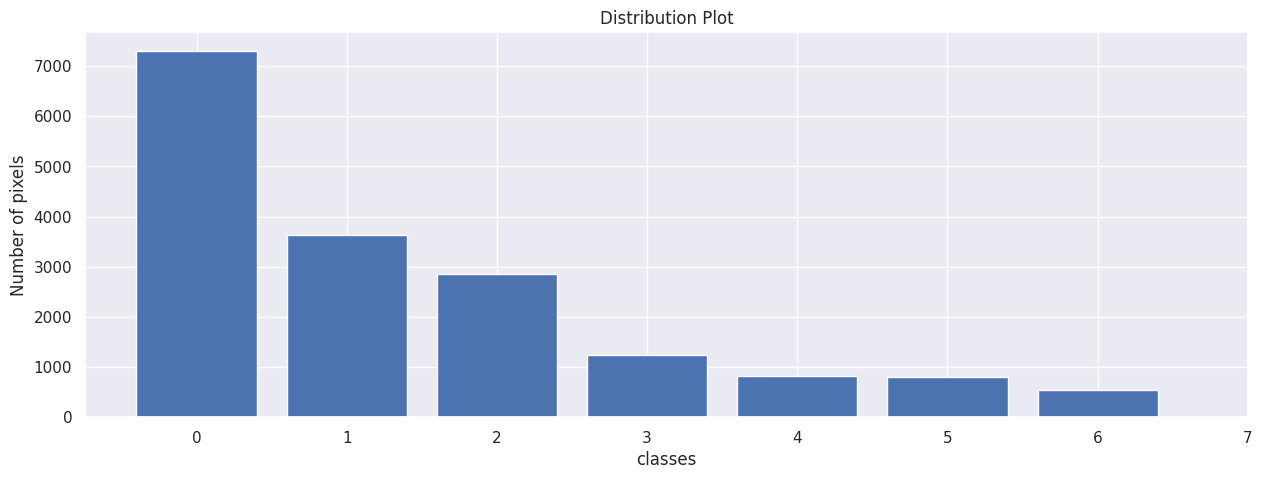

x_train: (12929, 9, 9, 6)
x_test:  (4310, 9, 9, 6)
y_train: (12929,)
y_test:  (4310,)


In [5]:
# Approximate RGB visualisation (middle three bands)
Approximate_rgb_img = x[:, :, [B // 2 - 1, B // 2, B // 2 + 1]] * 255

class_labels, value_counts = np.unique(y.reshape(-1, 1), return_counts=True)
plt.figure(figsize=(15, 5))
plt.bar(class_labels[1:] - 1, value_counts[1:])
plt.xticks(class_labels, rotation=0)
plt.xlabel('classes')
plt.ylabel('Number of pixels')
plt.title('Distribution Plot')
plt.show()

x_train, x_test, y_train, y_test = train_test_split(
    X, Y, train_size=(train_percent / 100), stratify=Y, random_state=10
)
print(
    f'x_train: {x_train.shape}\n'
    f'x_test:  {x_test.shape}\n'
    f'y_train: {y_train.shape}\n'
    f'y_test:  {y_test.shape}'
)

# 3.0 — Shared Metrics, Layers, and Callbacks

Define visualisation helpers, classification metric reporting, the Pearson-correlation
attention layer, a staged-dropout layer, and the custom training callback used by all
three models.

## 3.1 — Visualisation & Metric Helpers

`plot_accuracy_loss_curve` overlays accuracy and loss on dual axes.
`performance_meausures` (name preserved as-is for backward compatibility) renders a
4-panel figure: classification report, confusion matrix, score summary, and parameter
count — and now correctly returns the figure for downstream export.

In [6]:
def plot_accuracy_loss_curve(history, use_pearson_corr=None, folder_path=None):
    """Plot and optionally save training accuracy and loss curves."""
    train_loss     = history.history['loss']
    val_loss       = history.history['val_loss']
    train_accuracy = history.history['accuracy']
    val_accuracy   = history.history['val_accuracy']

    fig = plt.figure(figsize=(24, 8))
    ax  = plt.subplot(1, 1, 1)
    ax2 = ax.twinx()

    ax.plot(train_accuracy, color='blue',  marker='o', linewidth=1.5, markersize=2, label='train_accuracy')
    ax.plot(val_accuracy,   color='green', marker='o', linewidth=1.5, markersize=2, label='val_accuracy')
    ax.grid()
    ax.legend()
    plt.xlabel('no. of epoches')
    plt.ylabel('accuracy')

    ax2.plot(train_loss, color='black', marker='o', linewidth=1.5, markersize=2, label='train_loss')
    ax2.plot(val_loss,   color='red',   marker='o', linewidth=1.5, markersize=2, label='val_loss')
    ax2.grid()
    ax2.legend()
    plt.xlabel('no. of epoches')
    plt.ylabel('loss')
    plt.title('accuracy and loss plot for model performance')
    plt.show()

    if folder_path:
        results_dir = os.path.join(folder_path, "Results")
        os.makedirs(results_dir, exist_ok=True)
        prefix = "Pearson_Corr " if use_pearson_corr else ""
        path   = os.path.join(results_dir, f"{prefix}{train_percent}% ps_{P_S} accuracy_loss.png")
        fig.savefig(path)


def performance_meausures(y_test, y_pred, tt, *parameters_summary, folder_path=None):
    """Compute and visualize classification metrics; returns the figure for export.

    NOTE: function name has a typo ('meausures') — preserved for backward compatibility.
    """
    Total_params, Trainable_params, Non_trainable_params = parameters_summary
    accuracy = accuracy_score(y_test, y_pred)
    kappa    = cohen_kappa_score(y_test, y_pred)
    cm       = confusion_matrix(y_test, y_pred).astype('int32')
    cr       = classification_report(y_test, y_pred, output_dict=True)
    df_cr    = pd.DataFrame(cr).T
    df_score = pd.DataFrame({
        'accuracy score: ':  [accuracy],
        'Cohen_Kappa score: ': [kappa],
        "Training Time: ":  [tt],
    }).T
    df_summary = pd.DataFrame({
        'Total_params: ':       [Total_params],
        'Trainable_params: ':   [Trainable_params],
        'Non_trainable_params: ': [Non_trainable_params],
    }).T

    spec = gridspec.GridSpec(
        ncols=2, nrows=2, width_ratios=[1, 3],
        wspace=0.5, hspace=0.5, height_ratios=[7, 1],
    )
    fig = plt.figure(figsize=(24, 10))

    ax1 = fig.add_subplot(spec[0])
    ax1.set_title('classification report')
    sns.heatmap(df_cr, cmap='Blues', cbar=False, annot=True, fmt=' .5g', ax=ax1)

    ax2 = fig.add_subplot(spec[1])
    ax2.set_title('confusion matrix')
    ax2.set_xlabel('predicted class')
    ax2.set_ylabel('actual class')
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt=' .5g', ax=ax2)

    ax3 = fig.add_subplot(spec[2])
    sns.heatmap(df_score, cmap='Blues', cbar=False, annot=True, fmt=' .5g', ax=ax3)
    ax3.set_xticks([])

    ax4 = fig.add_subplot(spec[3])
    sns.heatmap(df_summary, cmap="Blues", cbar=False, annot=True, fmt=' .10g', ax=ax4)
    ax4.set_xticks([])

    if folder_path:
        path = folder_path + "Results/" + str(train_percent) + "% ps_" + str(P_S) + " Performance Measure.png"
        fig.savefig(path)

    return fig  # FIX: was missing; run_training used plt.gcf() as a workaround

## 3.2 — Custom Keras Layers

`Pearson_correlation_masked` computes a spatial Pearson-correlation attention mask
relative to the central pixel.  `Dropout_Train` implements deterministic channel-shift
dropout, cycling through channel groups across training shifts rather than random zeroing.

In [7]:
class Pearson_correlation_masked(layers.Layer):
    """Apply a Pearson-correlation attention mask to image patches."""

    def __init__(self, P_S=9, **kwargs):
        """Initialize with patch size P_S."""
        super(Pearson_correlation_masked, self).__init__(**kwargs)
        self.P_S = P_S

    def call(self, inputs):
        """Compute per-pixel Pearson correlation with the central patch pixel and apply as attention."""
        loc      = self.P_S // 2
        channels = inputs.shape[-1]

        # Mean of each pixel's spectral vector across channels
        x_mean = tf.repeat(tf.math.reduce_mean(inputs, axis=-1, keepdims=True), repeats=channels, axis=-1)

        # Central pixel, tiled to match spatial extent
        y = tf.repeat(
            tf.repeat(inputs[:, loc:loc+1, loc:loc+1, :], repeats=self.P_S, axis=-2),
            repeats=self.P_S, axis=-3,
        )
        y_mean = tf.repeat(tf.math.reduce_mean(y, axis=-1, keepdims=True), repeats=channels, axis=-1)

        a  = tf.math.subtract(inputs, x_mean)
        b  = tf.math.subtract(y, y_mean)
        ab = tf.math.multiply(a, b)

        num    = tf.math.reduce_sum(ab, axis=-1, keepdims=True)
        a_sq   = tf.math.reduce_sum(tf.math.multiply(a, a), axis=-1, keepdims=True)
        b_sq   = tf.math.reduce_sum(tf.math.multiply(b, b), axis=-1, keepdims=True)
        deno   = tf.math.sqrt(tf.math.multiply(a_sq, b_sq))
        corr   = tf.math.divide(num, deno)

        # Threshold at mean correlation; apply mask
        thresh         = tf.math.reduce_mean(corr)
        mask           = tf.cast(corr > thresh, corr.dtype)
        masked_corr    = tf.math.multiply(mask, corr)
        attention_wts  = tf.repeat(masked_corr, repeats=channels, axis=-1)

        return multiply([inputs, attention_wts])

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(Pearson_correlation_masked, self).get_config()
        config.update({"P_S": self.P_S})
        return config


@keras_export('keras.layers.Dropout')
class Dropout_Train(layers.Layer):
    """Deterministic channel-shift dropout applied during training only.

    Instead of random zeroing, successive shifts zero out a different contiguous
    slice of channels, ensuring every channel is trained without being dropped.
    """

    def __init__(self, rate, shift=1, noise_shape=None, seed=None, **kwargs):
        """Initialize with dropout rate and current shift index."""
        super(Dropout_Train, self).__init__(**kwargs)
        if isinstance(rate, (int, float)) and not 0 <= rate <= 1:
            raise ValueError(f"Invalid value {rate} received for `rate`, expected a value between 0 and 1.")
        if not isinstance(shift, int):
            raise TypeError(f"Invalid dtype {type(shift)} found for `shift`. It must be an integer")
        if shift * rate > 1.0:
            raise ValueError(
                f"Invalid value {shift} received for `shift`, "
                f"expected an integer value less than or equal to {int(1 / rate)}"
            )
        self.rate         = rate
        self.shift        = shift
        self.noise_shape  = noise_shape
        self.seed         = seed
        self.supports_masking = True

    def _get_noise_shape(self, inputs):
        """Resolve the concrete dropout noise shape from symbolic noise_shape."""
        if self.noise_shape is None:
            return None
        concrete_inputs_shape = array_ops.shape(inputs)
        noise_shape = []
        for i, value in enumerate(self.noise_shape):
            noise_shape.append(concrete_inputs_shape[i] if value is None else value)
        return tf.convert_to_tensor(noise_shape)

    def call(self, inputs, training=None):
        """Apply channel-shift dropout when training; identity otherwise."""
        if self.rate == 0:
            return tf.identity(inputs)
        if training is None:
            training = K.learning_phase()

        def dropped_inputs():
            """Build and apply the binary channel mask for this shift."""
            input_shape = inputs.shape
            range_0     = int(self.rate * (self.shift - 1) * input_shape[-1])
            range_1     = (
                int(self.rate * self.shift * input_shape[-1])
                if self.shift * self.rate < 1.0
                else None
            )
            multiplier              = np.ones(input_shape[-1])
            multiplier[range_0:range_1] = 0.0
            multiplier              = tf.constant(multiplier)
            return Multiply()([inputs, multiplier])

        return control_flow_util.smart_cond(training, dropped_inputs, lambda: array_ops.identity(inputs))

    def compute_output_shape(self, input_shape):
        """Output shape is unchanged from input shape."""
        return input_shape

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(Dropout_Train, self).get_config()
        config.update({
            "rate":            self.rate,
            "shift":           self.shift,
            "noise_shape":     self.noise_shape,
            "seed":            self.seed,
            "supports_masking": self.supports_masking,
        })
        return config

## 3.3 — Model Modifier & Training Callback

`modified_model` rebuilds a Keras model, replacing layers whose name contains
`layer_name` with a new layer instance (used to advance the dropout shift stage).
`Custom_callbacks` orchestrates staged training: it triggers `modified_model` each
time the validation accuracy threshold is met, cycling through all dropout shifts
before finalising and saving the best weights.

In [8]:
def modified_model(model, layer_name, rate, new_layer, shift, **kwargs):
    """Rebuild `model`, replacing layers matching `layer_name` with `new_layer`.

    layer_name: substring to match in layer names (case-insensitive)
    shift:      int → Dropout_Train shift index; str → standard Dropout (e.g. 'Final')
    """
    name         = kwargs.get("name", None)
    x            = model.layers[0].output
    modification = False
    z            = 0

    for lyr in model.layers[1:]:
        if (layer_name in lyr.name or layer_name in lyr.name.upper()) and isinstance(shift, int):
            x = new_layer(rate=rate, shift=shift, name=f"{layer_name}_{shift}_{z}")(x)
            modification = True
            z += 1
        elif (layer_name in lyr.name or layer_name in lyr.name.upper()) and isinstance(shift, str):
            x = new_layer(rate=rate, name=f"{layer_name}_{shift}_{z}")(x)
            modification = True
            z += 1
        else:
            x = lyr(x)

    if not modification:
        print("___________________________________Model has not been modified___________________________________")
    return Model(inputs=model.layers[0].input, outputs=x, name=name)


class Custom_callbacks(tf.keras.callbacks.Callback):
    """Manage staged dropout-shift training and best-weight restoration.

    Advances the dropout shift whenever val_accuracy >= accuracy_score AND
    at least min_epochs epochs have been completed in the current shift.
    After all shifts, saves the model with the best observed val_accuracy.
    """

    def __init__(self, filepath, epochs, rate, new_layer=Dropout_Train,
                 layer_name="DROPOUT", accuracy_score=0.99, min_epochs=50):
        """Configure staged training parameters."""
        super(Custom_callbacks, self).__init__()
        self.filepath       = filepath
        self.epochs         = epochs
        self.new_layer      = new_layer
        self.rate           = rate
        self.best           = 0.0
        self.epoch_num      = 1
        self.layer_name     = layer_name
        self.min_epochs     = min_epochs   # minimum epochs per shift before advancing
        self.accuracy_score = accuracy_score if accuracy_score <= 1.0 else accuracy_score / 100.0

    def on_train_begin(self, logs=None):
        """Initialise shift counter and apply the first shift to the model."""
        print(self.epochs)
        self.shift           = 1
        self.epoch_completed = 0
        print(f"Model will be trained in {int(1 / self.rate)} shifts")
        print("Starting training with 1st shift \n")
        self.model = modified_model(self.model, self.layer_name, self.rate, self.new_layer, self.shift)

    def on_train_end(self, logs=None):
        """Verify all shifts completed, restore best weights, and save the model."""
        if self.shift <= int(1 / self.rate):
            raise NotImplementedError(
                f"model has not trained fully in the available no. of epochs\n"
                f" only {self.shift - 1} shifts completed out of {int(1 / self.rate)}"
            )
        print("Model training completition ", "███████████" * self.shift, (self.rate * (self.shift - 1)) * 100, "%")
        print(f"Model has been fully trained in {int(1 / self.rate)} shifts")
        self.model.set_weights(self.best_weights)
        print(f"\nSaving best model to {self.filepath}")
        self.model.save(self.filepath)

    def on_epoch_end(self, epoch, logs=None):
        """Advance the shift or record best weights depending on current training state."""
        self.epoch_completed += 1
        self.epoch_num       += 1
        total_shifts          = int(1 / self.rate)
        acc                   = logs.get("val_accuracy", 0.0)
        threshold_met         = (acc >= self.accuracy_score) and (self.epoch_completed >= self.min_epochs)

        if threshold_met and self.shift < total_shifts:
            # Advance to the next dropout shift
            print("\nTargeted accuracy has been achieved")
            print("Model training completition ", "███████████" * self.shift, (self.rate * self.shift) * 100, "%")
            self.shift          += 1
            suffix               = "nd" if self.shift == 2 else "th"
            print(f"Modifying the model for {self.shift}{suffix} shift")
            self.model           = modified_model(self.model, self.layer_name, self.rate, self.new_layer, self.shift)
            self.epoch_completed = 0

        elif threshold_met and self.shift == total_shifts:
            # All shifts done — switch to standard Dropout for the final phase
            print("\nModel training completition ", "███████████" * self.shift, (self.rate * self.shift) * 100, "%")
            print("All shifting has been completed\n")
            print("██████████████████████===============> Now redefining the model to standard model <===============██████████████████████")
            self.model           = modified_model(self.model, self.layer_name, self.rate, self.new_layer, "Final", name="AlexNet")
            self.shift          += 1
            self.epoch_completed = 0

        else:
            print(", need more training")
            # Record best weights in the final (post-shift) stage
            if self.shift >= total_shifts:
                current = logs.get("val_accuracy")
                if not np.less(current, self.best) and (self.epoch_num >= self.epochs - 10):
                    print(f"val_accuracy improved from {self.best:.4f} to {current:.4f}")
                    self.best         = current
                    self.best_weights = self.model.get_weights()

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(Custom_callbacks, self).get_config()
        config.update({
            "filepath":       self.filepath,
            "epochs":         self.epochs,
            "new_layer":      self.new_layer,
            "rate":           self.rate,
            "best":           self.best,
            "epoch_num":      self.epoch_num,
            "layer_name":     self.layer_name,
            "min_epochs":     self.min_epochs,
            "accuracy_score": self.accuracy_score,
        })
        return config

# 4.0 — AlexNet Multi-Head Model

A five-block convolutional backbone (AlexNet-style) followed by three dense layers,
each guarded by a `Dropout` layer named `TRAIN_DROPOUT_*` (targeted by `Custom_callbacks`).
The backbone fans out to `K_HEADS = 7` independent softmax output heads.

In [9]:
def AlexNet(input_shape, num_classes=13, use_pearson_corr=False, dropout_rate=0.5):
    """Build the multi-head AlexNet-style convolutional classifier."""
    K_HEADS = 7  # number of independent output heads

    x_input = Input(input_shape)
    X = Pearson_correlation_masked(P_S)(x_input) if use_pearson_corr else x_input

    # ── Convolutional backbone ────────────────────────────────────────────
    X = Conv2D(filters=96,  kernel_size=(3, 3), activation='relu', strides=(1, 1), padding='same')(X)
    X = Conv2D(filters=256, kernel_size=(3, 3), activation='relu', strides=(1, 1), padding='same')(X)
    X = Conv2D(filters=384, kernel_size=(3, 3), activation='relu', strides=(1, 1), padding='same')(X)
    X = Conv2D(filters=384, kernel_size=(3, 3), activation='relu', strides=(1, 1), padding='same')(X)
    X = Conv2D(filters=256, kernel_size=(3, 3), activation='relu', strides=(1, 1), padding='same')(X)
    X = MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same')(X)

    # ── Dense head ───────────────────────────────────────────────────────
    X = Flatten()(X)
    X = Dense(4096, activation='relu')(X)
    X = Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(X)
    X = Dense(1024, activation='relu')(X)
    X = Dropout(dropout_rate, name="TRAIN_DROPOUT_2")(X)
    X = Dense(256,  activation='relu')(X)
    X = Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(X)
    X = Dense(32,   activation='relu')(X)

    # ── Multi-head outputs ────────────────────────────────────────────────
    output_heads = [
        Dense(num_classes, activation='softmax', dtype='float32', name=f'head_{i+1}')(X)
        for i in range(K_HEADS)
    ]
    return Model(inputs=x_input, outputs=output_heads, name="MultiHead_AlexNet")

# 5.0 — GFNet Multi-Head Model

GFNet replaces self-attention with a learned global filter in the frequency domain
(2-D real FFT → element-wise complex multiply → inverse FFT).  This section defines
all supporting layer classes and the multi-head GFNet builder.

## 5.1 — GFNet Layer Classes

`GF_MLP`, `GF_DropPath`, `GF_Expand_Dims`, `GF_Patches`, `GF_PatchEncoder`,
`GF_GlobalFilter`, and `GF_Block` form the GFNet primitive vocabulary.

> **Fixes applied:** `GF_Expand_Dims.config` and `GF_GlobalFilter.config` were
> incorrectly named (missing `get_` prefix); both renamed to `get_config` so Keras
> serialisation works correctly.

In [10]:
class GF_MLP(layers.Layer):
    """Feed-forward MLP block used by the GFNet architecture."""

    def __init__(self, in_features, out_features, drop=0.0, **kwargs):
        """Initialize with in/out feature dims and dropout rate."""
        super(GF_MLP, self).__init__(**kwargs)
        self.in_features  = in_features
        self.out_features = out_features
        self.drop         = drop
        self.mlp_1  = Dense(in_features,  activation=activations.gelu, use_bias=False)
        self.drop_1 = Dropout(drop)
        self.mlp_2  = Dense(out_features, activation=activations.gelu, use_bias=False)
        self.drop_2 = Dropout(drop)

    def call(self, x):
        """Forward pass: two GELU dense layers with dropout."""
        x = self.drop_1(self.mlp_1(x))
        x = self.drop_2(self.mlp_2(x))
        return x

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(GF_MLP, self).get_config()
        config.update({"in_features": self.in_features, "out_features": self.out_features, "drop": self.drop})
        return config


class GF_DropPath(layers.Layer):
    """Stochastic depth (DropPath) regularization for residual paths."""

    def __init__(self, drop_prob=0.0, training=False, **kwargs):
        """Initialize with drop probability."""
        super(GF_DropPath, self).__init__(**kwargs)
        self.drop_prob = drop_prob
        self.training  = training

    def call(self, x, **kwargs):
        """Apply stochastic depth; identity when drop_prob==0 or not training."""
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob     = 1 - self.drop_prob
        shape         = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + tf.random.uniform(shape, dtype=x.dtype)
        random_tensor.floor_()   # binarize
        return tf.divide(x, keep_prob) * random_tensor

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(GF_DropPath, self).get_config()
        config.update({"drop_prob": self.drop_prob, "training": self.training})
        return config


class GF_Expand_Dims(layers.Layer):
    """Expand tensor dimensions along `ndim` for GFNet compatibility."""

    def __init__(self, ndim, **kwargs):
        """Initialize with axis index to expand."""
        super(GF_Expand_Dims, self).__init__(**kwargs)
        self.ndim = ndim

    def call(self, x):
        """Insert a dimension at axis `ndim`."""
        return tf.expand_dims(x, axis=self.ndim)

    def get_config(self, **kwargs):  # FIX: was incorrectly named `config`; corrected to `get_config`
        """Return serializable Keras configuration."""
        config = super(GF_Expand_Dims, self).get_config()
        config.update({"ndim": self.ndim})
        return config


class GF_Patches(layers.Layer):
    """Extract image patches for the GFNet backbone.

    Supports two methods:
    - 'conv':    strided Conv2D projection (shape → [B, N, hidden_dim])
    - 'extract': tf.image.extract_patches (shape → [B, N, patch_dim])
    """

    def __init__(self, patch_size=3, hidden_dim=256, patch_method='extract', **kwargs):
        """Initialize patch extractor with size, projection dim, and method."""
        super(GF_Patches, self).__init__(**kwargs)
        self.patch_size   = patch_size
        self.hidden_dim   = hidden_dim
        self.patch_method = patch_method.lower()

    def call(self, images):
        """Extract patches via Conv2D or tf.image.extract_patches."""
        if self.patch_method == "conv":
            x       = Conv2D(self.hidden_dim, self.patch_size, self.patch_size)(images)
            patches = Reshape([-1, x.shape[-1]])(x)
            return patches
        else:
            batch_size = tf.shape(images)[0]
            patches    = tf.image.extract_patches(
                images=images,
                sizes=[1, self.patch_size, self.patch_size, 1],
                strides=[1, self.patch_size, self.patch_size, 1],
                rates=[1, 1, 1, 1],
                padding="VALID",
            )
            patch_dims = patches.shape[-1]
            return tf.reshape(patches, [batch_size, -1, patch_dims])

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(GF_Patches, self).get_config()
        config.update({"patch_size": self.patch_size, "hidden_dim": self.hidden_dim, "patch_method": self.patch_method})
        return config


class GF_PatchEncoder(layers.Layer):
    """Project GFNet patches to `projection_dim` and add positional embeddings."""

    def __init__(self, num_patches, projection_dim, **kwargs):
        """Initialize with patch count and projection dimensionality."""
        super(GF_PatchEncoder, self).__init__(**kwargs)
        self.num_patches    = num_patches
        self.projection_dim = projection_dim
        self.projection        = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patch, **kwargs):
        """Project patches and add sinusoidal-free learned positional embeddings."""
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patch) + self.position_embedding(positions)

    def get_config(self, **kwargs):
        """Return serializable Keras configuration."""
        config = super(GF_PatchEncoder, self).get_config()
        config.update({"num_patches": self.num_patches, "projection_dim": self.projection_dim})
        return config


class GF_GlobalFilter(layers.Layer):
    """Apply the Global Filter operation: FFT → learned complex multiply → IFFT."""

    def __init__(self, patch_size, dim, **kwargs):
        """Initialize with spatial patch size and feature dimensionality."""
        super(GF_GlobalFilter, self).__init__(**kwargs)
        self.patch_size = patch_size
        self.dim        = dim

    def build(self, input_shape):
        """Create the learnable complex weight tensor."""
        w_init = tf.random_uniform_initializer()
        self.complex_weight = self.add_weight(
            name="complex_weight",
            shape=(self.patch_size, self.patch_size, input_shape[-1] // 2 + 1, 2),
            initializer=w_init,
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x, **kwargs):
        """Apply real-valued 2-D FFT filtering with learned complex weights."""
        B, N, C = x.shape
        a       = b = int(math.sqrt(N))
        x       = tf.reshape(x, [-1, a, b, C])
        x       = tf.signal.rfft2d(x)
        weight  = tf.dtypes.complex(self.complex_weight[:, :, :, 0], self.complex_weight[:, :, :, -1])
        x       = x * weight
        x       = tf.signal.irfft2d(x)
        return tf.reshape(x, [-1, N, C])

    def get_config(self, **kwargs):  # FIX: was incorrectly named `config`; corrected to `get_config`
        """Return serializable Keras configuration."""
        config = super(GF_GlobalFilter, self).get_config()
        config.update({"patch_size": self.patch_size, "dim": self.dim})
        return config


class GF_Block(tf.keras.layers.Layer):
    """One GFNet block: LayerNorm → GlobalFilter → DropPath residual → LayerNorm → MLP → DropPath residual."""

    def __init__(self, patch_size=3, dim=512, mlp_ratio=4.0, drop=0.0, drop_path=0.0, **kwargs):
        """Initialize GFNet block with filter and MLP hyperparameters."""
        super(GF_Block, self).__init__(**kwargs)
        self.patch_size    = patch_size
        self.dim           = dim
        self.mlp_ratio     = mlp_ratio
        self.drop          = drop
        self.drop_path_rate = drop_path

        self.norm1     = tf.keras.layers.LayerNormalization(axis=-1)
        self.filter    = GF_GlobalFilter(patch_size, dim)
        self.drop_path = GF_DropPath(drop_path)
        self.norm2     = tf.keras.layers.LayerNormalization(axis=-1)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp       = GF_MLP(in_features=mlp_hidden_dim, out_features=dim, drop=drop)

    def call(self, x):
        """Single residual block: filter branch + MLP branch."""
        x = x + self.drop_path(self.mlp(self.norm2(self.filter(self.norm1(x)))))
        return x

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(GF_Block, self).get_config()
        config.update({
            "patch_size": self.patch_size,
            "dim":        self.dim,
            "mlp_ratio":  self.mlp_ratio,
            "drop":       self.drop,
            "drop_path":  self.drop_path_rate,
        })
        return config

## 5.2 — GFNet Model Builder

Assembles patch extraction, encoder, `GlobalFilter_layers` GFNet blocks, pooling,
and `K_HEADS = 7` softmax output heads.

In [11]:
def GFNet(input_shape=(P_S, P_S, B),
          use_pearson_corr=False,
          patch_size=3,
          num_classes=16,
          hidden_dim=512,
          GlobalFilter_layers=12,
          mlp_ratio=4,
          num_patches=9,
          dropout_rate=0.0,
          drop_path_rate=0.0):
    """Build the multi-head GFNet classifier."""
    K_HEADS = 7  # number of independent output heads

    x_input = Input(shape=input_shape)
    x = Pearson_correlation_masked(P_S)(x_input) if use_pearson_corr else x_input

    # ── Patch extraction and encoding ────────────────────────────────────
    x = GF_Patches(patch_size)(x)
    x = GF_PatchEncoder(num_patches, hidden_dim)(x)
    x = Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(x)

    # ── Stacked Global Filter blocks ─────────────────────────────────────
    for _ in range(GlobalFilter_layers):
        x = GF_Block(
            patch_size=patch_size,
            dim=hidden_dim,
            mlp_ratio=mlp_ratio,
            drop=dropout_rate,
            drop_path=drop_path_rate,
        )(x)

    # ── Pooling and normalisation ─────────────────────────────────────────
    x = Dropout(dropout_rate, name="TRAIN_DROPOUT_2")(x)
    x = LayerNormalization()(x)
    x = GF_Expand_Dims(ndim=2)(x)
    x = GlobalAveragePooling2D()(x)
    x = Flatten()(x)
    x = Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(x)

    # ── Multi-head outputs ─────────────────────────────────────────────────
    output_heads = [
        Dense(num_classes, activation="softmax", dtype="float32", name=f"head_{i+1}")(x)
        for i in range(K_HEADS)
    ]
    return keras.Model(inputs=x_input, outputs=output_heads, name="MultiHead_GFNet")

# 6.0 — Vision Transformer Multi-Head Model

A compact ViT with learnable CLS token, positional embeddings, and a symmetric
U-Net-style skip-connection transformer stack (`ViT_TransFormer_Block`).
Optional spatial-attention preprocessing modules are also defined here.

## 6.1 — ViT Layer Classes

`ViT_SpatialAttention`, `ViT_SpatialAttention1`, `MLP` (functional),
`ViT_Patches`, `ViT_PatchEncoder` (with CLS token), `ViT_Weighted_add`,
`ViT_TransFormer`, `ViT_TransFormer_Block` (symmetric skips), and
`ViT_Class_Token_Norm`.

In [12]:
class ViT_SpatialAttention(layers.Layer):
    """Four-conv spatial attention gate producing a sigmoid attention map."""

    def __init__(self, k_size=3, **kwargs):
        """Initialize with convolution kernel size."""
        super().__init__(**kwargs)
        self.k_size     = k_size
        self.norm       = layers.BatchNormalization()
        self.conv1      = layers.Conv2D(1, kernel_size=(k_size, k_size), padding="same")
        self.conv2      = layers.Conv2D(1, kernel_size=(k_size, k_size), padding="same")
        self.conv3      = layers.Conv2D(1, kernel_size=(k_size, k_size), padding="same")
        self.conv4      = layers.Conv2D(1, kernel_size=(k_size, k_size), padding="same")
        self.act_relu    = layers.Activation("relu")
        self.act_sigmoid = layers.Activation("sigmoid")

    def call(self, inputs):
        """Pass through four convolutions with ReLU; final sigmoid gate."""
        x = self.conv1(inputs)
        x = self.norm(x)
        x = self.conv2(x)
        x = self.act_relu(x)
        x = self.conv3(x)
        x = self.act_relu(x)
        x = self.conv4(x)
        return self.act_sigmoid(x)

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super().get_config()
        config.update({"k_size": self.k_size})
        return config


class ViT_SpatialAttention1(layers.Layer):
    """Encoder-decoder spatial attention gate with Conv2D + Conv2DTranspose."""

    def __init__(self, input_shape, **kwargs):
        """Initialize with expected input spatial shape for shape correction."""
        super().__init__(**kwargs)
        self.input_shape_val = input_shape
        self.filters         = input_shape[-1]
        self.k_size          = input_shape[1]

        self.norm    = layers.BatchNormalization()
        self.conv1   = layers.Conv2D(self.filters, kernel_size=3, padding="same", kernel_initializer="he_normal")
        self.conv2   = layers.Conv2D(self.filters, kernel_size=3, strides=2, padding="same")
        self.conv3   = layers.Conv2D(self.filters, kernel_size=3, strides=2, padding="same")
        self.convt1  = layers.Conv2DTranspose(self.filters, kernel_size=3, strides=2, padding="same")
        self.convt2  = layers.Conv2DTranspose(self.filters, kernel_size=3, strides=2, padding="same")
        self.relu    = layers.ReLU()
        self.sigmoid = layers.Activation("sigmoid")

    def call(self, inputs):
        """Encoder–decoder path with shape correction and sigmoid gate."""
        x = self.relu(self.norm(self.conv1(inputs)))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.convt1(x))
        x = self.relu(self.convt2(x))
        # Shape correction if stride misalignment occurs
        if x.shape[1] != self.input_shape_val[1] or x.shape[2] != self.input_shape_val[2]:
            k_size = x.shape[1] - self.k_size + 1
            x = layers.Conv2D(self.filters, kernel_size=k_size, strides=1, padding="valid")(x)
        return self.sigmoid(x)

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super().get_config()
        config.update({"input_shape": self.input_shape_val, "filters": self.filters, "k_size": self.k_size})
        return config


def MLP(x, hidden_units, dropout_rate):
    """Feedforward network used inside Transformer blocks.

    hidden_units: list of Dense layer sizes (e.g. [mlp_dim, embed_dim])
    dropout_rate: dropout applied after each Dense layer
    """
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


class ViT_Patches(layers.Layer):
    """Extract non-overlapping patches and project to `embed_dim`."""

    def __init__(self, patch_size, embed_dim=768, **kwargs):
        """Initialize with patch size and embedding dimension."""
        super(ViT_Patches, self).__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim  = embed_dim

    def build(self, input_shape):
        """Build the linear projection layer."""
        self.projection = layers.Dense(self.embed_dim)

    def call(self, images):
        """Extract patches via tf.image.extract_patches and project them."""
        batch_size = tf.shape(images)[0]
        patches    = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]   # = patch_size * patch_size * C
        patches    = tf.reshape(patches, [batch_size, -1, patch_dims])
        return self.projection(patches)  # project raw patches → embed_dim

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(ViT_Patches, self).get_config()
        config.update({"patch_size": self.patch_size, "embed_dim": self.embed_dim})
        return config


class ViT_PatchEncoder(layers.Layer):
    """Prepend a learnable CLS token and add positional embeddings to ViT patches."""

    def __init__(self, num_patches, projection_dim, **kwargs):
        """Initialize with patch count and projection dimensionality."""
        super(ViT_PatchEncoder, self).__init__(**kwargs)
        self.num_patches    = num_patches
        self.projection_dim = projection_dim
        self.projection      = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches + 1, output_dim=projection_dim)
        # Learnable CLS token initialised to zeros
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, projection_dim),
            initializer=tf.zeros_initializer(),
            trainable=True,
        )

    def call(self, patch, **kwargs):
        """Prepend CLS token, project patches, and add positional embeddings."""
        batch_size  = tf.shape(patch)[0]
        patch_proj  = self.projection(patch)                           # [B, N, D]
        cls_tokens  = tf.repeat(self.cls_token, repeats=batch_size, axis=0)  # [B, 1, D]
        x           = tf.concat([cls_tokens, patch_proj], axis=1)     # [B, N+1, D]
        positions   = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        return x + self.position_embedding(positions)

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(ViT_PatchEncoder, self).get_config()
        config.update({"num_patches": self.num_patches, "projection_dim": self.projection_dim})
        return config


class ViT_Weighted_add(layers.Layer):
    """Combine two tensors with a single learned scalar weight `w`: w*x + (1-w)*y."""

    def __init__(self, name, **kwargs):
        """Initialize with a unique identifier for the weight."""
        super(ViT_Weighted_add, self).__init__(**kwargs)
        self.wt_name = name

    def build(self, input_shape):
        """Create the scalar blend weight."""
        self.w = self.add_weight(
            name="weighted_add_" + str(self.wt_name),
            shape=(1,),
            initializer=tf.random_normal_initializer(),
            trainable=True,
        )

    def call(self, input_1, input_2):
        """Weighted residual blend."""
        return input_1 * self.w + input_2 * (1.0 - self.w)

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(ViT_Weighted_add, self).get_config()
        config.update({"wt_name": self.wt_name})
        return config


class ViT_TransFormer(layers.Layer):
    """Single transformer block: Multi-Head Attention + FFN, both with learned-weight residuals."""

    def __init__(self, layer_num, num_heads, projection_dim, dropout=0.1, **kwargs):
        """Initialize block with layer index, head count, projection dim, and dropout."""
        super(ViT_TransFormer, self).__init__(**kwargs)
        self.layer_num      = layer_num
        self.num_heads      = num_heads
        self.projection_dim = projection_dim
        self.dropout        = dropout

    def build(self, input_shape):
        """Build sub-layers (deferred so `layer_num` is in scope for naming)."""
        self.norm1 = layers.LayerNormalization(epsilon=1e-6, name=f"ln1_{self.layer_num}")
        self.norm2 = layers.LayerNormalization(epsilon=1e-6, name=f"ln2_{self.layer_num}")
        self.add1  = ViT_Weighted_add(f"transformer_1_{self.layer_num}")
        self.add2  = ViT_Weighted_add(f"transformer_2_{self.layer_num}")
        self.mha   = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.projection_dim,
            dropout=self.dropout,
            name=f"mha_{self.layer_num}",
        )
        self.dense1 = layers.Dense(self.projection_dim * 2, activation=tf.keras.activations.gelu)
        self.drop1  = layers.Dropout(self.dropout)
        self.dense2 = layers.Dense(self.projection_dim,     activation=tf.keras.activations.gelu)
        self.drop2  = layers.Dropout(self.dropout)

    def call(self, inputs, training=None):
        """MHA residual block then FFN residual block."""
        # Multi-Head Attention
        x1 = self.norm1(inputs)
        x1 = self.mha(x1, x1, training=training)
        x1 = self.add1(x1, inputs)
        # Feed-Forward Network
        x2 = self.norm2(x1)
        x2 = self.drop1(self.dense1(x2), training=training)
        x2 = self.drop2(self.dense2(x2), training=training)
        return self.add2(x2, x1)

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(ViT_TransFormer, self).get_config()
        config.update({
            "layer_num": self.layer_num, "num_heads": self.num_heads,
            "projection_dim": self.projection_dim, "dropout": self.dropout,
        })
        return config


class ViT_TransFormer_Block(layers.Layer):
    """Stack of `num_layers` transformer blocks with symmetric U-Net-style skip connections."""

    def __init__(self, num_layers, num_heads, projection_dim, dropout=0.1, **kwargs):
        """Initialize block stack with depth, head count, projection dim, and dropout."""
        super(ViT_TransFormer_Block, self).__init__(**kwargs)
        self.num_layers     = num_layers
        self.num_heads      = num_heads
        self.projection_dim = projection_dim
        self.dropout        = dropout

    def build(self, input_shape):
        """Build the list of TransFormer sub-layers."""
        self.Blocks = [
            ViT_TransFormer(i, self.num_heads, self.projection_dim, self.dropout)
            for i in range(self.num_layers)
        ]

    def call(self, inputs, training=None):
        """Forward + symmetric skip connections (mirror like U-Net)."""
        block_list = []
        x = inputs
        for i in range(self.num_layers):
            x = self.Blocks[i](x, training=training)
            if i <= self.num_layers // 2:
                block_list.append(x)
            else:
                x = layers.Add()([x, block_list[self.num_layers - i - 1]])
        return x

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(ViT_TransFormer_Block, self).get_config()
        config.update({
            "num_layers": self.num_layers, "num_heads": self.num_heads,
            "projection_dim": self.projection_dim, "dropout": self.dropout,
        })
        return config


class ViT_Class_Token_Norm(layers.Layer):
    """Apply LayerNormalization and return only the CLS token (index 0)."""

    def __init__(self, eps=1e-6, **kwargs):
        """Initialize with LayerNorm epsilon."""
        super(ViT_Class_Token_Norm, self).__init__(**kwargs)
        self.eps  = eps
        self.norm = layers.LayerNormalization(epsilon=self.eps)

    def call(self, inputs):
        """Normalize sequence and extract CLS token → shape (B, D)."""
        x = self.norm(inputs)
        return x[:, 0, :]   # CLS token

    def get_config(self):
        """Return serializable Keras configuration."""
        config = super(ViT_Class_Token_Norm, self).get_config()
        config.update({"eps": self.eps})
        return config

## 6.2 — ViT Model Builder

`create_vit_classifier` assembles the full pipeline.  Three representation strategies
are supported via the `method` argument: `with_cls_tkn` (CLS token), `with_gap`
(global average pooling), and `without_gap` (flattened normalization).

> **Note:** `projection_dim`, `num_heads`, `transformer_layers`, and `dropout` are
> referenced as free variables from the enclosing scope.  The authoritative values are
> set in Section 7.0 (Training Configuration) below; the defaults here serve as
> documentation / fallbacks if Section 7.0 is not run first.

In [13]:
# Default ViT hyperparameters — overridden by Section 7.0
projection_dim     = 256
num_heads          = 4
transformer_layers = 12
dropout            = 0.1   # dropout inside Transformer blocks


def create_vit_classifier(input_shape=(P_S, P_S, B),
                          num_classes=7,
                          use_pearson_corr=False,
                          dropout_rate=0.25,
                          method="with_gap",
                          k_heads: int = 1):
    """Build a Vision Transformer classifier with optional multi-head outputs.

    k_heads == 1: returns a single logits tensor (shape [B, num_classes]).
    k_heads  > 1: returns a list of k_heads tensors [ (B, num_classes), ... ].
    method: 'with_cls_tkn' | 'with_gap' | 'without_gap'
    """
    inputs = layers.Input(shape=input_shape)
    x0     = Pearson_correlation_masked(P_S)(inputs) if use_pearson_corr else inputs

    # ── Patch creation & encoding ──────────────────────────────────────
    patches         = ViT_Patches(patch_size, embed_dim=projection_dim)(x0)
    encoded_patches = ViT_PatchEncoder(num_patches, projection_dim)(patches)

    # ── Transformer stack ──────────────────────────────────────────────
    encoded_patches = ViT_TransFormer_Block(transformer_layers, num_heads, projection_dim, dropout)(encoded_patches)
    encoded_patches = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(encoded_patches)

    # ── Representation strategy ────────────────────────────────────────
    if method == "with_cls_tkn":
        representation = ViT_Class_Token_Norm(eps=1e-6)(encoded_patches)
    elif method == "without_gap":
        representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        representation = layers.Flatten()(representation)
    elif method == "with_gap":
        representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        representation = tf.reduce_mean(representation, axis=1)   # [B, D]
    else:
        raise ValueError(f"Unknown method: {method}")

    # ── Classification MLP ─────────────────────────────────────────────
    x = layers.Dense(512, activation=tf.keras.activations.gelu)(representation)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(x)
    x = layers.Dense(256, activation=tf.keras.activations.gelu)(x)
    x = layers.Dense(128, activation=tf.keras.activations.gelu)(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_5")(x)
    x = layers.Dense(64,  activation=tf.keras.activations.gelu)(x)
    features = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_6")(x)

    # ── Multi-head outputs ──────────────────────────────────────────────
    output_heads = [
        layers.Dense(num_classes, activation="softmax", dtype="float32", name=f"head_{i+1}")(features)
        for i in range(max(1, k_heads))
    ]

    outputs = output_heads[0] if k_heads == 1 else output_heads
    return keras.Model(inputs=inputs, outputs=outputs)

# 7.0 — Training Configuration

Authoritative architecture hyperparameters (overriding any defaults set above),
the `CUSTOM_OBJECTS` dict required for model deserialisation, and `MODEL_SPECS` —
a registry mapping each model name to its builder, optimiser, LR schedule, and
output paths.

In [14]:
# ── Architecture hyperparameters (authoritative values) ────────────────────
# NOTE: projection_dim, num_heads, transformer_layers, dropout were also set in
# Section 6.2 as defaults; the values here take precedence at call time.
patch_size         = 3
hidden_dim         = 512
GlobalFilter_layers = 12
mlp_ratio          = 4
num_patches        = 9
projection_dim     = 256
num_heads          = 4
transformer_layers = 12
dropout            = 0.1

# ── Custom-object registry for model deserialisation ──────────────────────
CUSTOM_OBJECTS = {
    'Pearson_correlation_masked': Pearson_correlation_masked,
    'Dropout_Train':              Dropout_Train,
    'GF_Patches':                 GF_Patches,
    'GF_PatchEncoder':            GF_PatchEncoder,
    'GF_GlobalFilter':            GF_GlobalFilter,
    'GF_Block':                   GF_Block,
    'GF_Expand_Dims':             GF_Expand_Dims,
    'GF_MLP':                     GF_MLP,
    'GF_DropPath':                GF_DropPath,
    'ViT_Patches':                ViT_Patches,
    'ViT_PatchEncoder':           ViT_PatchEncoder,
    'ViT_SpatialAttention':       ViT_SpatialAttention,
    'ViT_SpatialAttention1':      ViT_SpatialAttention1,
    'ViT_Weighted_add':           ViT_Weighted_add,
    'ViT_TransFormer':            ViT_TransFormer,
    'ViT_TransFormer_Block':      ViT_TransFormer_Block,
    'ViT_Class_Token_Norm':       ViT_Class_Token_Norm,
}

# ── Per-model training specifications ─────────────────────────────────────
MODEL_SPECS = {
    'AlexNet_CNN_MultiHead': {
        'builder':    lambda: AlexNet(input_shape=(P_S, P_S, B), num_classes=num_classes,
                                      use_pearson_corr=use_pearson_corr, dropout_rate=dropout_rate),
        'optimizer':  lambda: optimizers.Adagrad(0.01),
        'lr_schedule': 'alexnet',
        'model_file': SAVED_MODEL_DIR / 'AlexNet_CNN_MultiHead_best.keras',
        'final_file': SAVED_MODEL_DIR / 'AlexNet_CNN_MultiHead_final.keras',
    },
    'GFNet_MultiHead': {
        'builder':    lambda: GFNet((P_S, P_S, B), use_pearson_corr, patch_size, num_classes,
                                    hidden_dim, GlobalFilter_layers, mlp_ratio, num_patches, dropout_rate, 0.0),
        'optimizer':  lambda: tf.keras.optimizers.Adam(learning_rate=0.000003),
        'lr_schedule': 'gfnet',
        'model_file': SAVED_MODEL_DIR / 'GFNet_MultiHead_best.keras',
        'final_file': SAVED_MODEL_DIR / 'GFNet_MultiHead_final.keras',
    },
    'ViT_UNet_MultiHead': {
        'builder':    lambda: create_vit_classifier(input_shape=(P_S, P_S, B), num_classes=num_classes,
                                                    use_pearson_corr=use_pearson_corr, dropout_rate=dropout_rate,
                                                    method='with_cls_tkn', k_heads=7),
        'optimizer':  lambda: optimizers.Adam(3e-6),
        'lr_schedule': 'vit',
        'model_file': SAVED_MODEL_DIR / 'ViT_UNet_MultiHead_best.keras',
        'final_file': SAVED_MODEL_DIR / 'ViT_UNet_MultiHead_final.keras',
    },
}

# 8.0 — Training and Export Helpers

Utility functions for workbook management, learning-rate scheduling, multi-head
prediction aggregation, performance metrics export, and the reusable training runner.

## 8.1 — Excel Export Utilities

`ensure_workbook` creates or opens the results workbook.
`autosize_columns` adjusts column widths.
`fig_to_buffer` serialises Matplotlib figures to PNG buffers for embedding.
`export_training_sheet` writes summary rows, classification reports, confusion matrices,
and three figures into a dedicated worksheet.

In [15]:
def ensure_workbook(path):
    """Create a new workbook with a Summary sheet, or load an existing one."""
    if path.exists():
        return load_workbook(path)
    wb = Workbook()
    ws = wb.active
    ws.title = 'Summary'
    wb.save(path)
    return wb


def autosize_columns(ws):
    """Resize each worksheet column to fit its widest cell value (max 40 chars)."""
    for col in ws.columns:
        values = [len(str(cell.value)) for cell in col if cell.value is not None]
        if values:
            ws.column_dimensions[col[0].column_letter].width = min(max(values) + 2, 40)


def fig_to_buffer(fig):
    """Serialise a Matplotlib figure to an in-memory PNG BytesIO buffer."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=200)
    buf.seek(0)
    return buf


def export_training_sheet(wb, model_name, summary_row, report_df, cm, figs):
    """Write metrics, classification report, confusion matrix, and figures to a new Excel sheet."""
    ws = wb.create_sheet(title=model_name[:31])

    # Summary key-value rows
    for idx, (key, value) in enumerate(summary_row.items(), start=1):
        ws.cell(row=idx, column=1, value=key)
        ws.cell(row=idx, column=2, value=value)

    row0 = len(summary_row) + 3

    # Classification report table
    for r_idx, row in enumerate(dataframe_to_rows(report_df.reset_index(), index=False, header=True), start=row0):
        for c_idx, val in enumerate(row, start=1):
            ws.cell(row=r_idx, column=c_idx, value=val)

    # Confusion matrix (offset to column 10)
    for r_idx, row in enumerate(dataframe_to_rows(pd.DataFrame(cm), index=False, header=False), start=row0):
        for c_idx, val in enumerate(row, start=10):
            ws.cell(row=r_idx, column=c_idx, value=int(val))

    # Embedded figures: curve, performance, LR schedule
    for anchor, fig in [('L2', figs[0]), ('L30', figs[1]), ('L58', figs[2])]:
        img        = XLImage(fig_to_buffer(fig))
        img.anchor = anchor
        ws.add_image(img)

    autosize_columns(ws)

## 8.2 — Learning Rate Scheduling

`build_lr_callback` builds a cosine-annealing `LearningRateScheduler` and plots the
schedule.  The AlexNet and GFNet variants use a **three-stage** multi-step cosine
decay; the ViT variant uses a single-stage cosine decay.

> **DRY refactor:** the identical multi-step cosine decay logic that was duplicated
> in the AlexNet and GFNet branches has been extracted into `_multistep_cosine_lrfn`.
> `LR_START` (which was assigned but never read in both branches) has been removed.

In [16]:
def _multistep_cosine_lrfn(e, steps, lr_max, lr_min):
    """Cosine-decay LR for a three-stage schedule.

    # DRY: consolidated repeated cosine decay logic from alexnet and gfnet branches
    stages: [0, steps[0]) → stage 1, [steps[0], steps[0]+steps[1]) → stage 2, else → stage 3
    """
    if e < steps[0]:
        epoch2, epochs2 = e, steps[0]
    elif e < steps[0] + steps[1]:
        epoch2, epochs2 = e - steps[0], steps[1]
    else:
        epoch2, epochs2 = e - steps[0] - steps[1], steps[2]
    phase = math.pi * epoch2 / (epochs2 - 1)
    return (lr_max - lr_min) * 0.5 * (1.0 + math.cos(phase)) + lr_min


def build_lr_callback(kind):
    """Build a LearningRateScheduler and return (callback, figure)."""
    if kind == 'alexnet':
        LR_MAX, LR_MIN = 0.02, 0.005
        STEPS = [epoch, epoch * 2, epoch * 3]
        lrfn  = lambda e: _multistep_cosine_lrfn(e, STEPS, LR_MAX, LR_MIN)   # DRY

    elif kind == 'gfnet':
        LR_MAX, LR_MIN = 6e-4, 1e-7
        STEPS = [epoch, epoch * 2, epoch * 3]
        lrfn  = lambda e: _multistep_cosine_lrfn(e, STEPS, LR_MAX, LR_MIN)   # DRY

    else:   # 'vit' and any other schedule: single-stage cosine decay
        LR_MAX, LR_MIN = 6e-4, 1e-7
        def lrfn(e):
            """Single-stage cosine-decay LR schedule."""
            phase = math.pi * e / (epoch - 1)
            return (LR_MAX - LR_MIN) * 0.5 * (1.0 + math.cos(phase)) + LR_MIN

    rng  = list(range(epoch))
    lr_y = [lrfn(x) for x in rng]
    fig  = plt.figure(figsize=(10, 4))
    plt.plot(rng, lr_y, '-o')
    plt.xlabel('Epoch', size=14)
    plt.ylabel('Learning Rate', size=14)
    plt.title(f'Learning rate schedule: {kind}')
    plt.show()
    return tf.keras.callbacks.LearningRateScheduler(lrfn, verbose=True), fig

## 8.3 — Prediction & Metric Helpers

`predict_multihead` averages probability distributions across all K heads and returns
argmax class predictions.  `parameter_summary` counts total / trainable / non-trainable
parameters.  `history_figure` plots head-1 accuracy and overall loss curves.

In [17]:
def predict_multihead(model, x_data):
    """Average multi-head probabilities and return (argmax labels, averaged probs)."""
    y_pred_list      = model.predict(x_data, verbose=0)
    y_pred_stacked   = np.stack(y_pred_list, axis=0)
    y_pred_avg_probs = np.mean(y_pred_stacked, axis=0)
    y_pred_argmax    = np.argmax(y_pred_avg_probs, axis=1)
    return y_pred_argmax.reshape(-1, 1), y_pred_avg_probs


def parameter_summary(model):
    """Return (total, trainable, non_trainable) parameter counts for a Keras model."""
    trainable     = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    non_trainable = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))
    return int(trainable + non_trainable), trainable, non_trainable


def history_figure(history, model_name):
    """Plot head-1 train/val accuracy and overall train/val loss; return the figure."""
    fig = plt.figure(figsize=(24, 8))
    ax  = plt.subplot(1, 1, 1)
    ax2 = ax.twinx()

    ax.plot(history.history.get('head_1_accuracy',     []), color='blue',  marker='o', linewidth=1.5, markersize=2, label='train_head_1_accuracy')
    ax.plot(history.history.get('val_head_1_accuracy', []), color='green', marker='o', linewidth=1.5, markersize=2, label='val_head_1_accuracy')
    ax.grid()
    ax.legend()

    ax2.plot(history.history.get('loss',     []), color='black', marker='o', linewidth=1.5, markersize=2, label='train_loss')
    ax2.plot(history.history.get('val_loss', []), color='red',   marker='o', linewidth=1.5, markersize=2, label='val_loss')
    ax2.legend()

    plt.title(f'accuracy and loss plot for {model_name}')
    plt.show()
    return fig

## 8.4 — Training Runner

`run_training` orchestrates the full cycle for a single model: build → compile →
fit → reload best checkpoint → evaluate → export to Excel.  Returns a summary dict
for the master summary sheet.

In [18]:
def run_training(model_name, spec, workbook):
    """Train, evaluate, save, and export results for one configured model."""
    tf.keras.backend.clear_session()
    gc.collect()

    model      = spec['builder']()
    lr_callback, lr_fig = build_lr_callback(spec['lr_schedule'])
    checkpoint = ModelCheckpoint(
        spec['model_file'],
        monitor='val_head_1_accuracy',
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='max',
    )
    model.compile(
        optimizer=spec['optimizer'](),
        loss=['sparse_categorical_crossentropy'] * 7,
        metrics=['accuracy'] * 7,
    )

    start_time = time.time()
    history    = model.fit(
        x_train, [y_train] * 7,
        validation_data=(x_test, [y_test] * 7),
        validation_freq=1,
        batch_size=BATCH_SIZE,
        callbacks=[checkpoint, lr_callback],
        shuffle=False,
        epochs=epoch,
    )
    tt = time.time() - start_time

    # Reload best checkpoint and copy to final path
    reloaded = load_model(spec['model_file'], custom_objects=CUSTOM_OBJECTS, safe_mode=False)
    shutil.copy2(spec['model_file'], spec['final_file'])

    # Evaluate
    y_pred, _                                  = predict_multihead(reloaded, x_test)
    total_params, trainable_params, non_trainable_params = parameter_summary(reloaded)
    accuracy  = float(accuracy_score(y_test, y_pred))
    kappa     = float(cohen_kappa_score(y_test, y_pred))
    cm        = confusion_matrix(y_test, y_pred)
    report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T

    # Generate figures (performance_meausures now returns fig directly)
    curve_fig = history_figure(history, model_name)
    perf_fig  = performance_meausures(
        y_test, y_pred, tt,
        total_params, trainable_params, non_trainable_params,
        folder_path=folder_path,
    )

    summary_row = {
        'model_name':          model_name,
        'best_model_path':     str(spec['model_file']),
        'final_model_path':    str(spec['final_file']),
        'test_accuracy':       accuracy,
        'cohen_kappa':         kappa,
        'training_time_sec':   float(tt),
        'total_params':        total_params,
        'trainable_params':    trainable_params,
        'non_trainable_params': non_trainable_params,
    }
    export_training_sheet(workbook, model_name, summary_row, report_df, cm, [curve_fig, perf_fig, lr_fig])
    return summary_row

# 9.0 — Main Training Execution

Iterate over `MODEL_SPECS`, run each model through `run_training`, populate the
Summary worksheet, and persist the workbook and model registry JSON.


============================== Training AlexNet_CNN_MultiHead ==============================


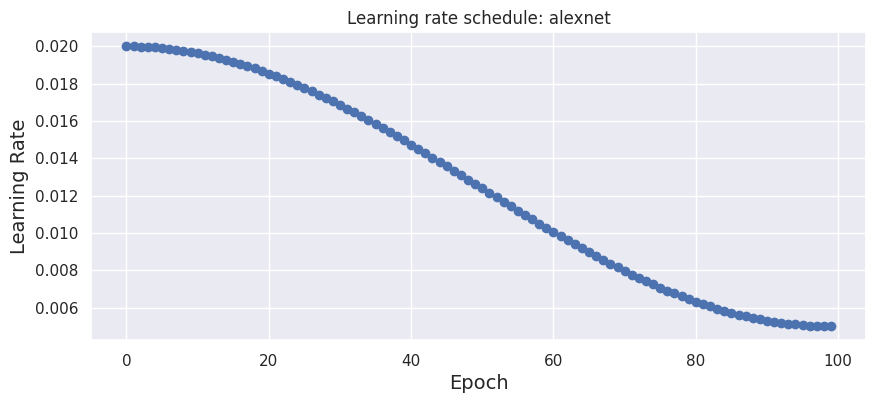


Epoch 1: LearningRateScheduler setting learning rate to 0.02.
Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - head_1_accuracy: 0.4073 - head_1_loss: 1.6977 - head_2_accuracy: 0.3398 - head_2_loss: 1.7464 - head_3_accuracy: 0.4029 - head_3_loss: 1.7110 - head_4_accuracy: 0.4062 - head_4_loss: 1.7422 - head_5_accuracy: 0.4046 - head_5_loss: 1.7099 - head_6_accuracy: 0.3698 - head_6_loss: 1.7147 - head_7_accuracy: 0.3773 - head_7_loss: 1.6937 - loss: 12.0167
Epoch 1: val_head_1_accuracy improved from None to 0.55012, saving model to /content/drive/My Drive/Classification/multicp/models/AlexNet_CNN_MultiHead_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/Classification/multicp/models/AlexNet_CNN_MultiHead_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 42s 226ms/step - head_1_accuracy: 0.4492 - head_1_loss: 1.5317 - head_2_accuracy: 0.4142 - head_2_loss: 1.5573 - head_3_accuracy: 0.4403 - head_3_loss: 1.5308 - head_4_accuracy: 0.4416 - head_4_loss: 1.5590 - head_5_

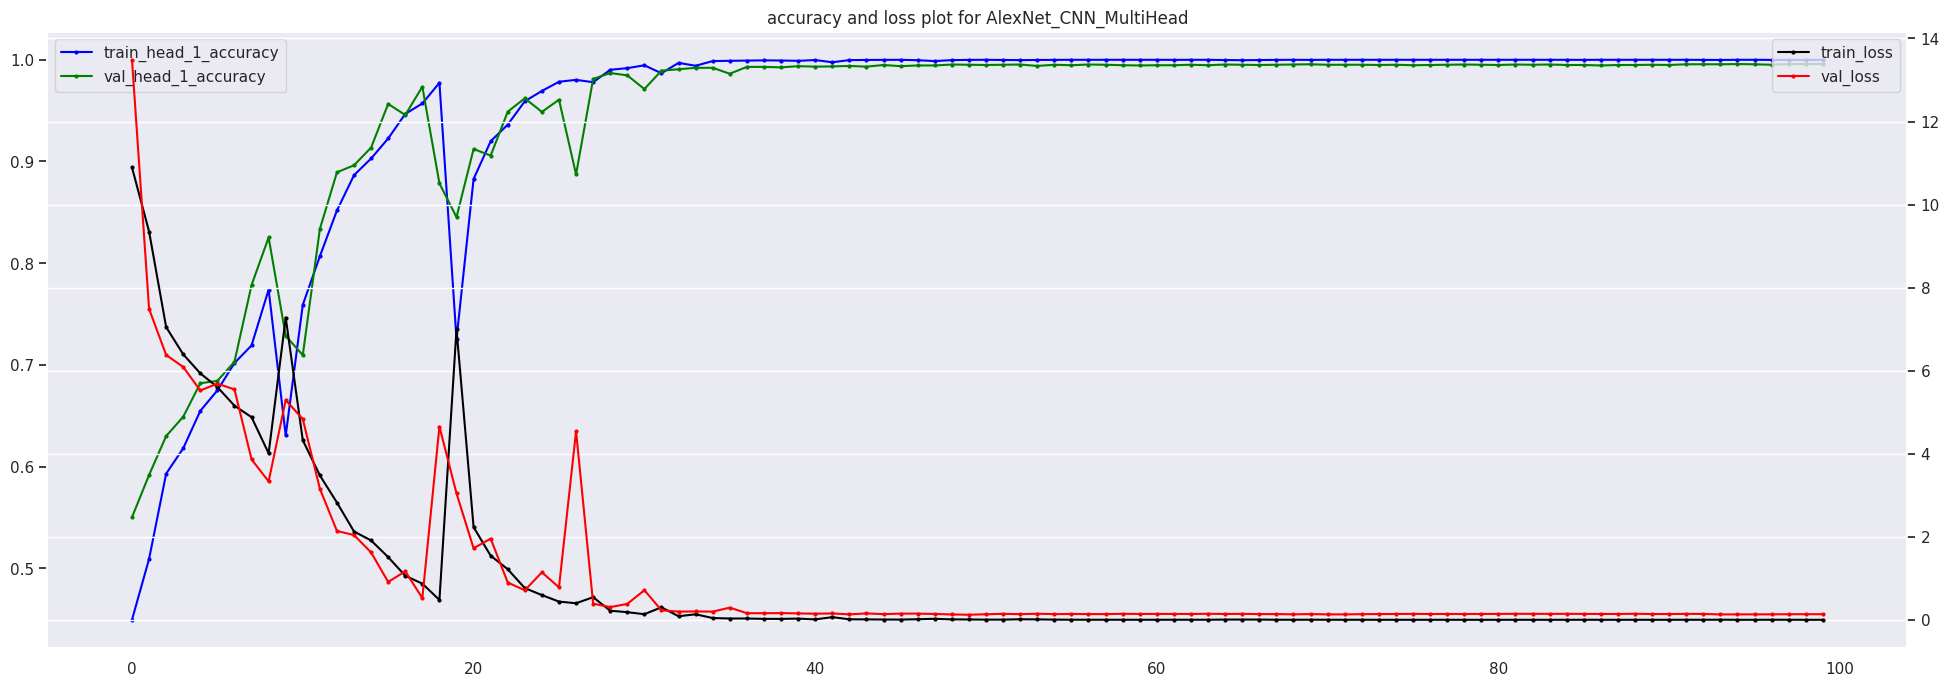


============================== Training GFNet_MultiHead ==============================


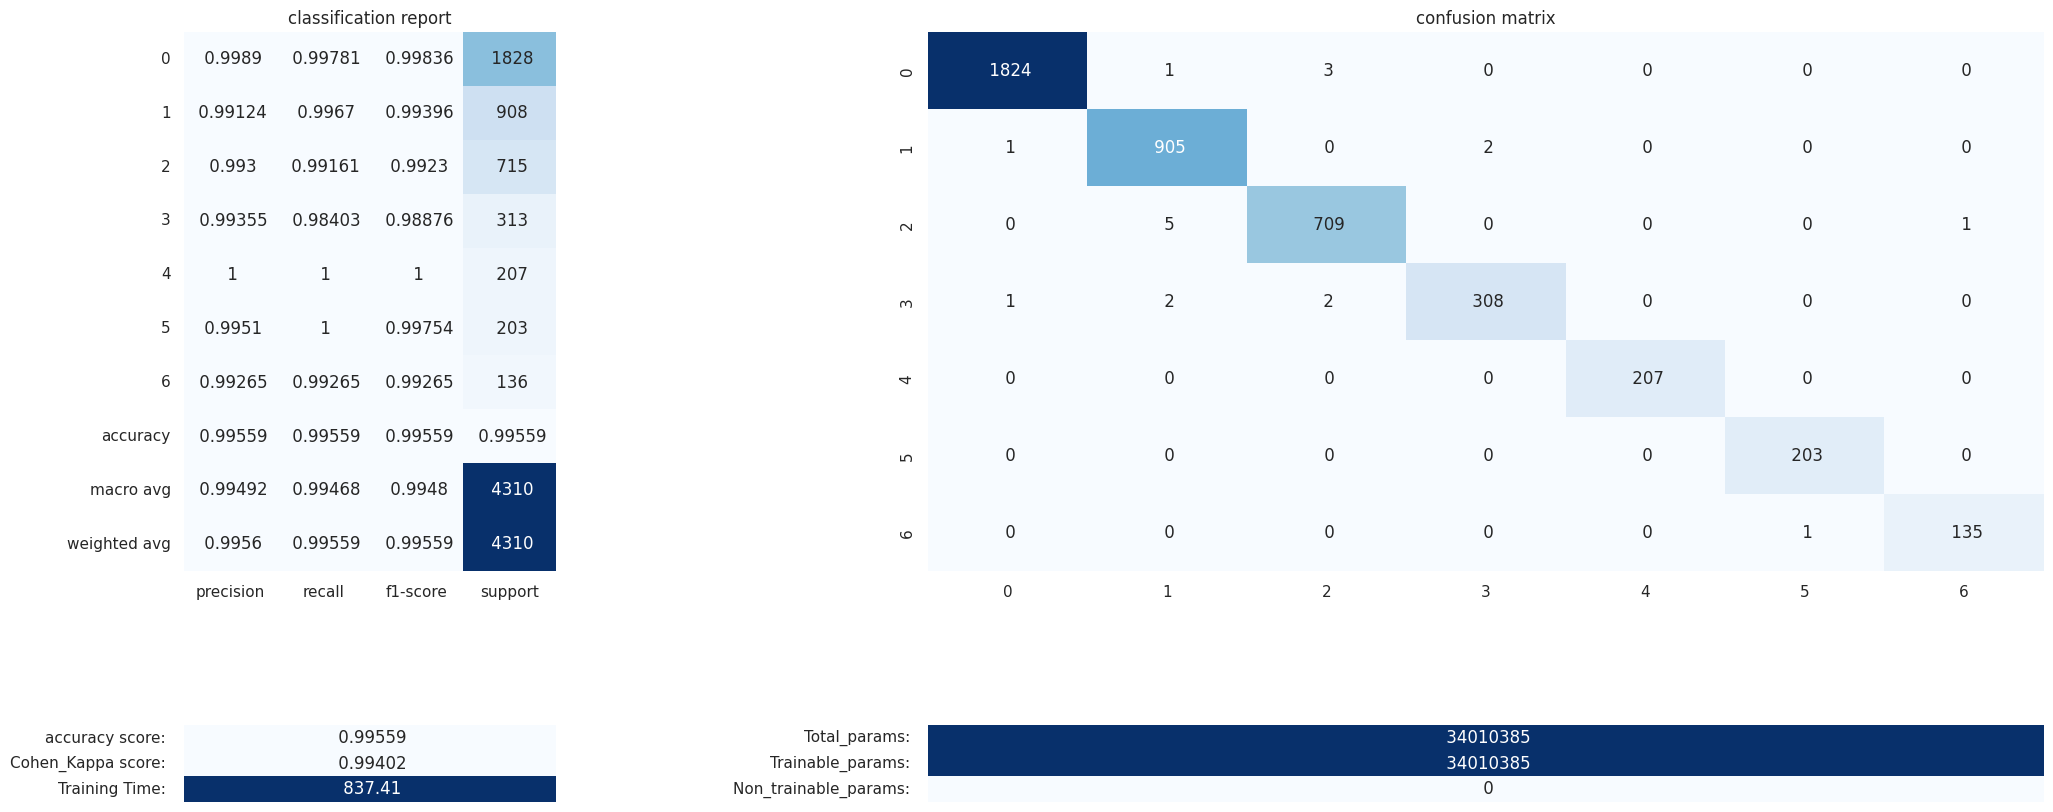

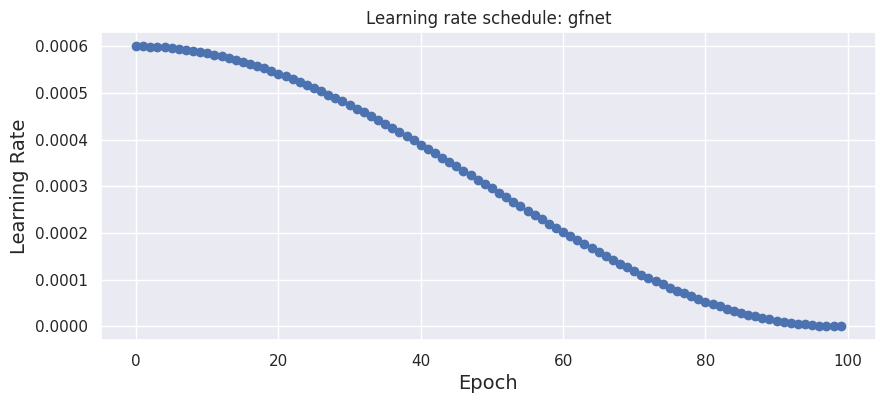


Epoch 1: LearningRateScheduler setting learning rate to 0.0006.
Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - head_1_accuracy: 0.4640 - head_1_loss: 1.5715 - head_2_accuracy: 0.4574 - head_2_loss: 1.6279 - head_3_accuracy: 0.4851 - head_3_loss: 1.4113 - head_4_accuracy: 0.4864 - head_4_loss: 1.4108 - head_5_accuracy: 0.4713 - head_5_loss: 1.4806 - head_6_accuracy: 0.4497 - head_6_loss: 1.5988 - head_7_accuracy: 0.4701 - head_7_loss: 1.4964 - loss: 10.5981
Epoch 1: val_head_1_accuracy improved from None to 0.70696, saving model to /content/drive/My Drive/Classification/multicp/models/GFNet_MultiHead_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/Classification/multicp/models/GFNet_MultiHead_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 124s 599ms/step - head_1_accuracy: 0.5544 - head_1_loss: 1.1778 - head_2_accuracy: 0.5476 - head_2_loss: 1.1973 - head_3_accuracy: 0.5668 - head_3_loss: 1.1285 - head_4_accuracy: 0.5605 - head_4_loss: 1.1330 - head_5_accuracy:

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__block_1', however the layer does 

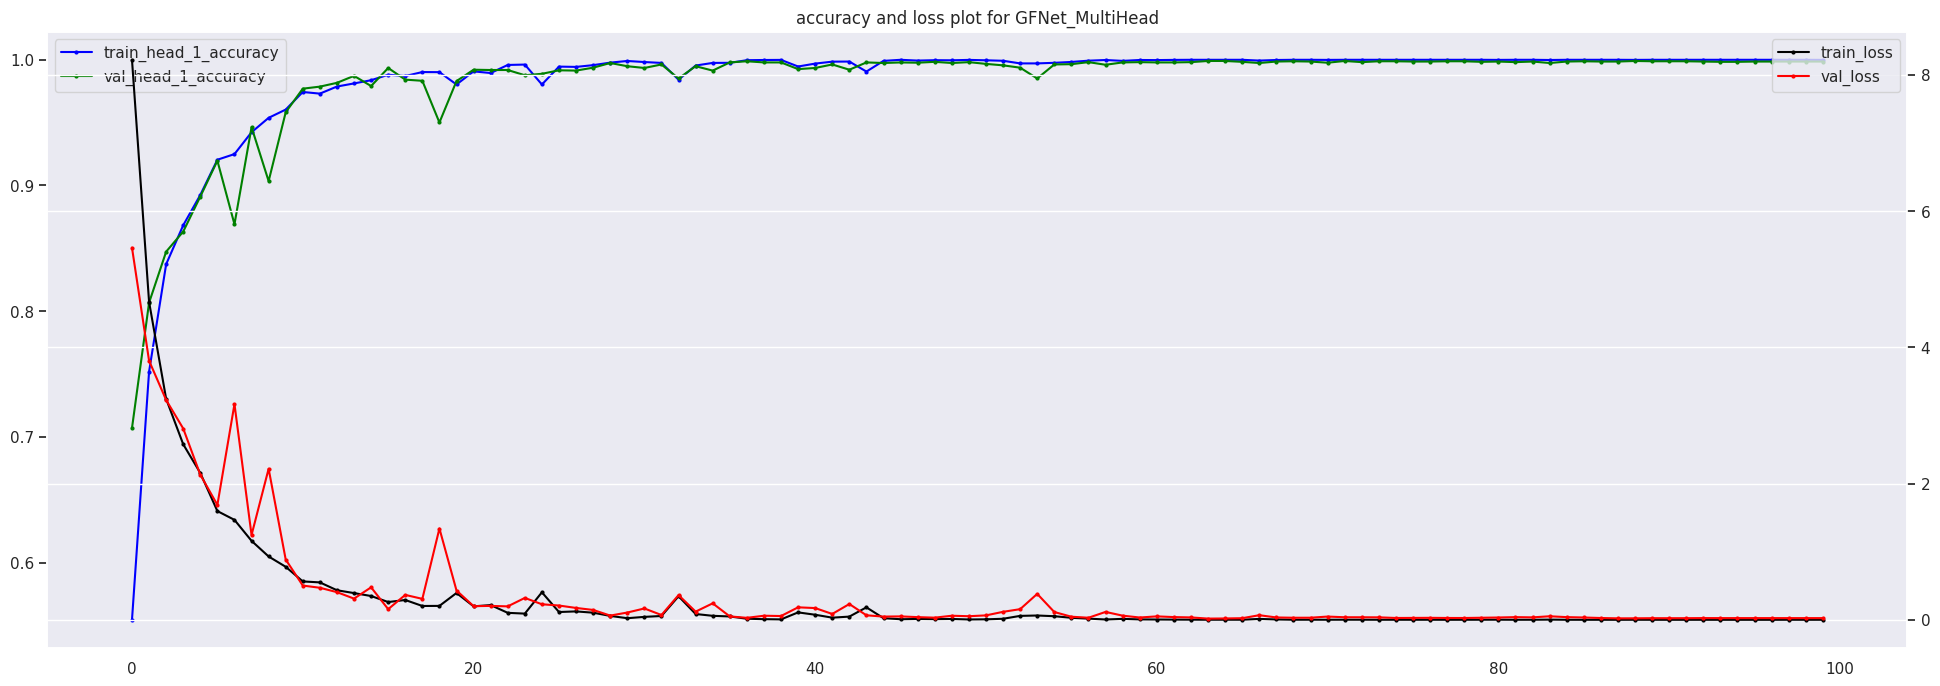


============================== Training ViT_UNet_MultiHead ==============================


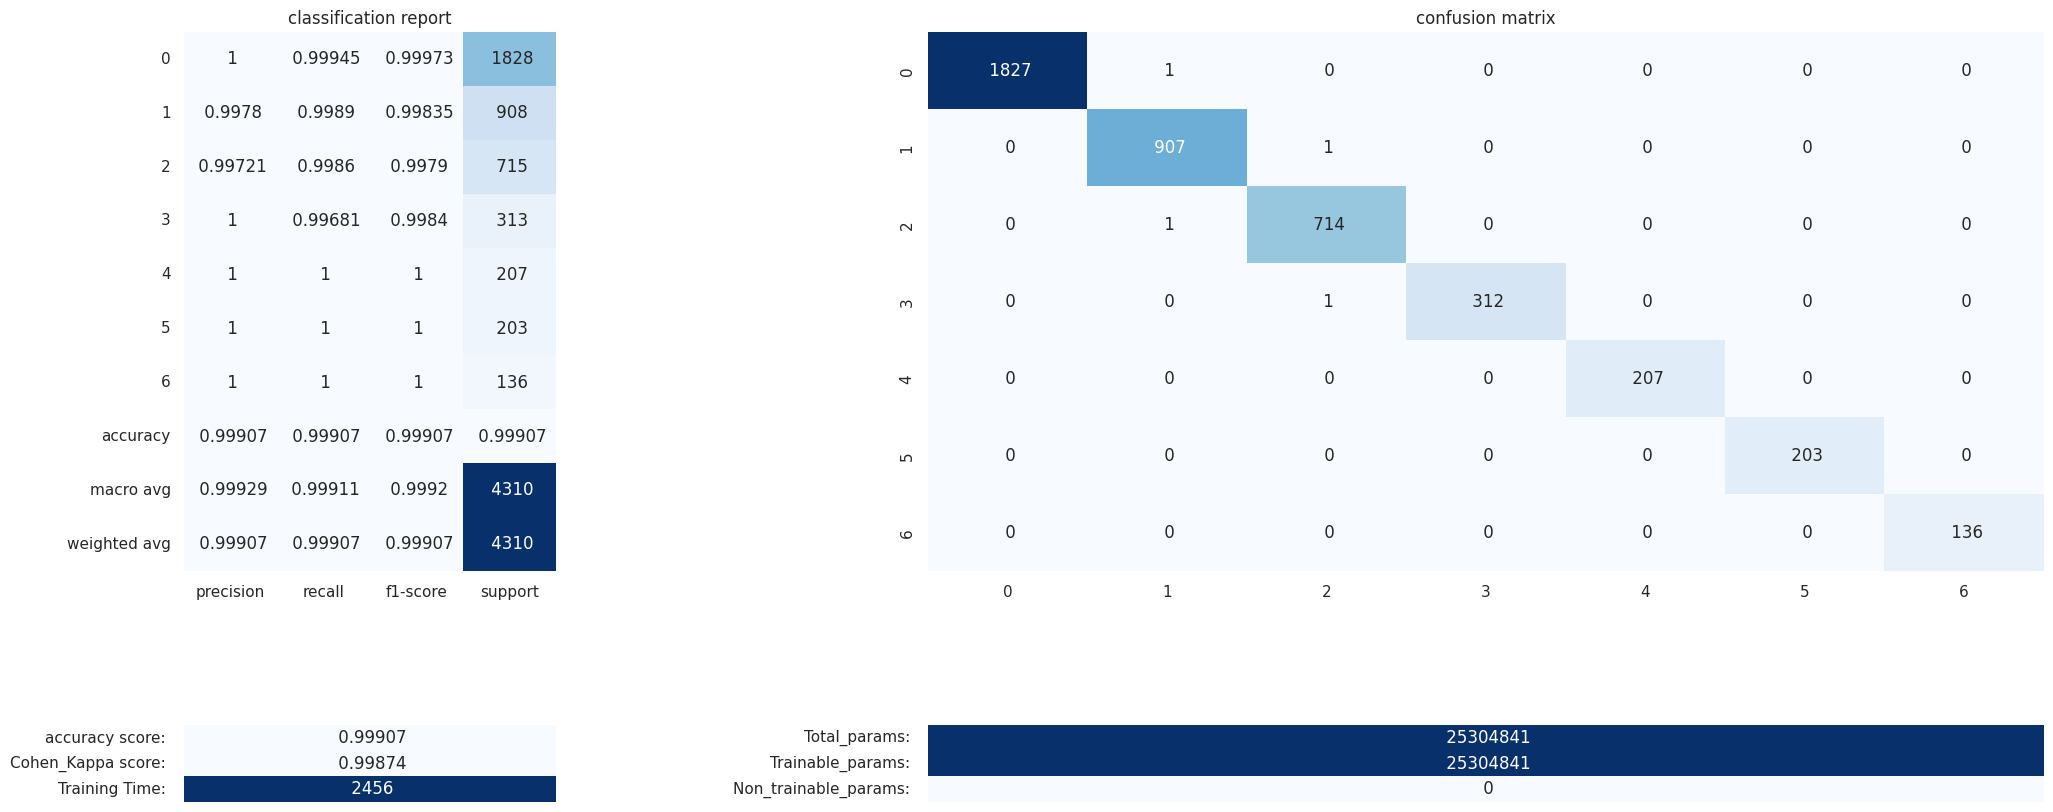

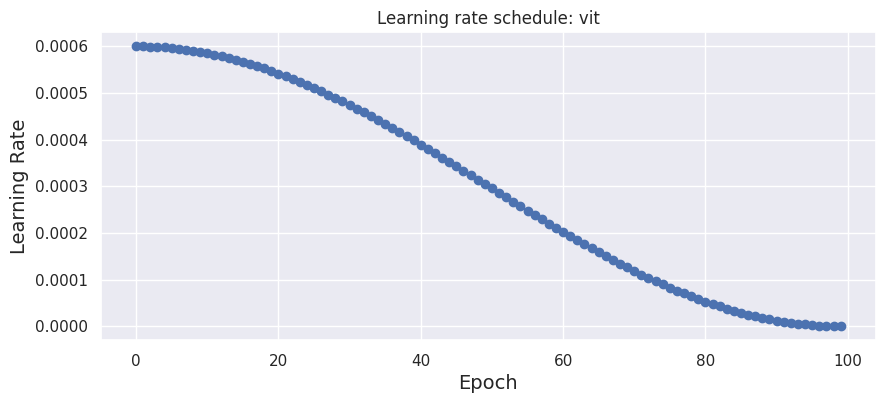


Epoch 1: LearningRateScheduler setting learning rate to 0.0006.
Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - head_1_accuracy: 0.4103 - head_1_loss: 1.4964 - head_2_accuracy: 0.4648 - head_2_loss: 1.4032 - head_3_accuracy: 0.4805 - head_3_loss: 1.3856 - head_4_accuracy: 0.4569 - head_4_loss: 1.3776 - head_5_accuracy: 0.4762 - head_5_loss: 1.3905 - head_6_accuracy: 0.4720 - head_6_loss: 1.4411 - head_7_accuracy: 0.4819 - head_7_loss: 1.3684 - loss: 9.8636
Epoch 1: val_head_1_accuracy improved from None to 0.78515, saving model to /content/drive/My Drive/Classification/multicp/models/ViT_UNet_MultiHead_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/Classification/multicp/models/ViT_UNet_MultiHead_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 200s 936ms/step - head_1_accuracy: 0.5432 - head_1_loss: 1.1880 - head_2_accuracy: 0.5688 - head_2_loss: 1.1521 - head_3_accuracy: 0.5778 - head_3_loss: 1.1304 - head_4_accuracy: 0.5616 - head_4_loss: 1.1332 - head_5_accu

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'vi_t__patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'vi_t__class__token__norm', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


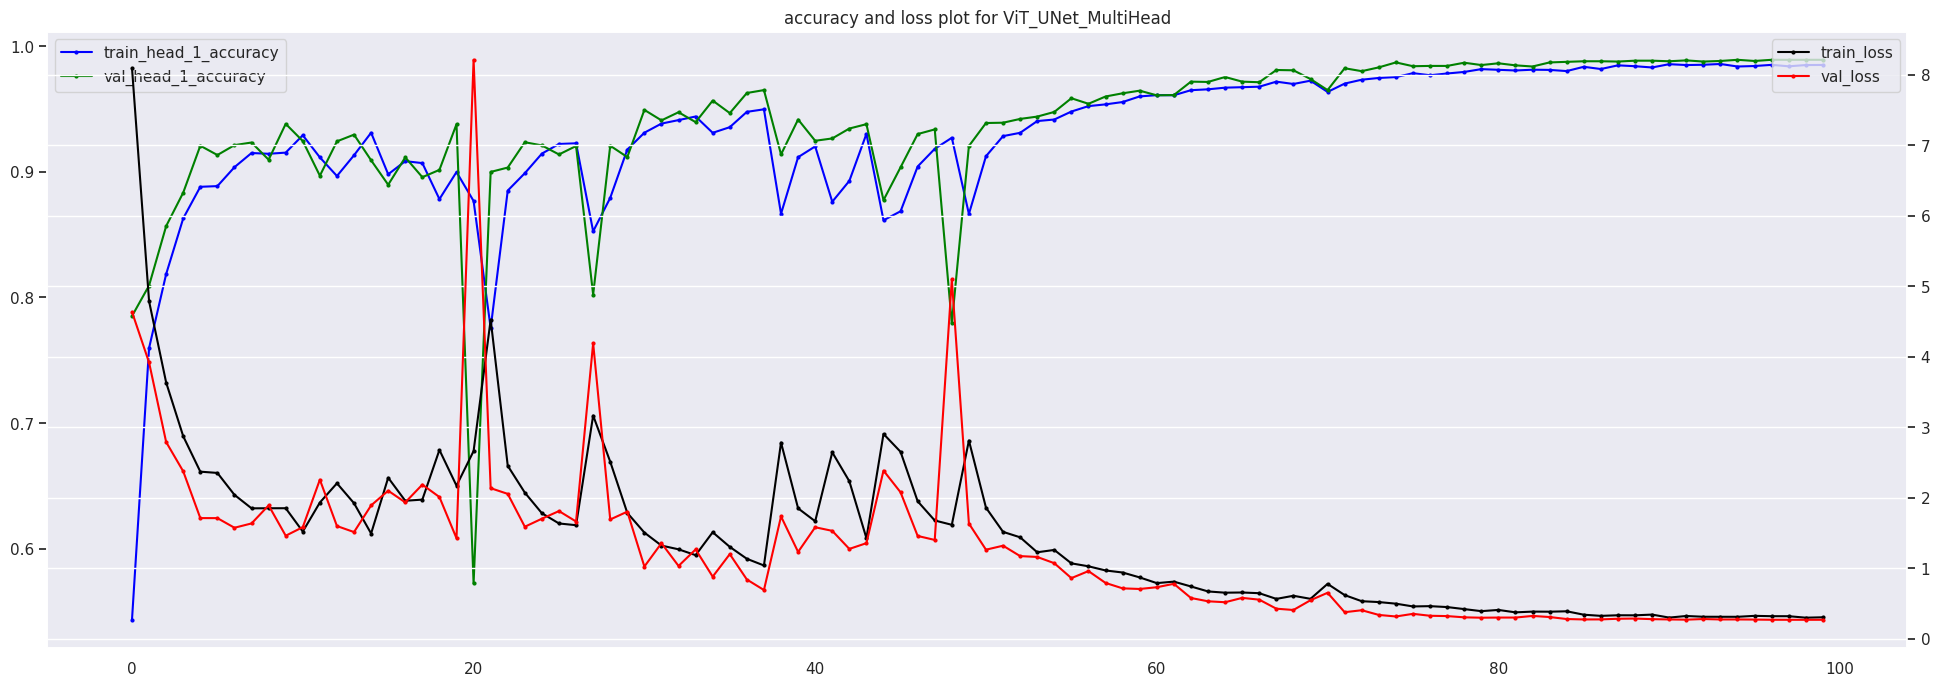

Saved training workbook to /content/drive/My Drive/Classification/multicp/models/model_training_multihead_results.xlsx
Saved model registry to /content/drive/My Drive/Classification/multicp/models/model_registry_multihead.json


,model_name,best_model_path,final_model_path,test_accuracy,cohen_kappa,training_time_sec,total_params,trainable_params,non_trainable_params
0,AlexNet_CNN_MultiHead,/content/drive/My Drive/Classification/multicp...,/content/drive/My Drive/Classification/multicp...,0.995592,0.994022,837.408769,34010385,34010385,0
1,GFNet_MultiHead,/content/drive/My Drive/Classification/multicp...,/content/drive/My Drive/Classification/multicp...,0.999072,0.998741,2455.998824,25304841,25304841,0
2,ViT_UNet_MultiHead,/content/drive/My Drive/Classification/multicp...,/content/drive/My Drive/Classification/multicp...,0.988631,0.984588,2106.346367,16180553,16180553,0


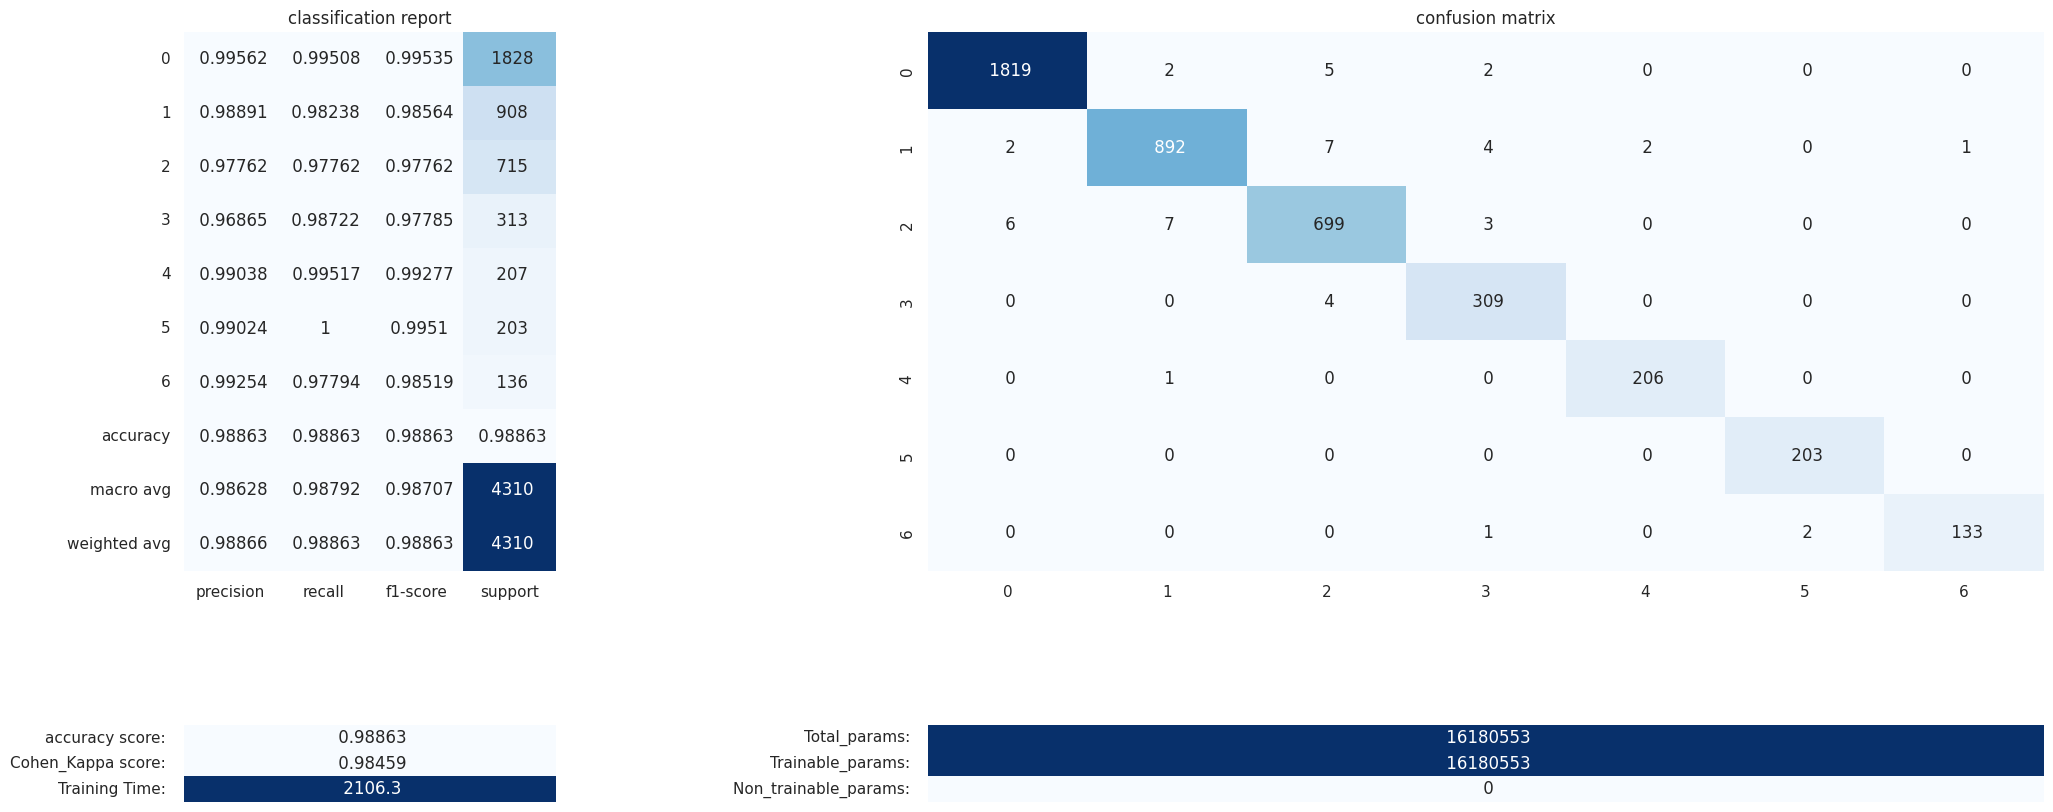

In [19]:
training_wb = ensure_workbook(TRAINING_WORKBOOK)

# Clear existing per-model sheets (keep Summary) to avoid stale data
if 'Summary' in training_wb.sheetnames and len(training_wb.sheetnames) > 1:
    for sheet in training_wb.sheetnames[1:]:
        del training_wb[sheet]

summary_rows = []
registry     = {}

for model_name, spec in MODEL_SPECS.items():
    print('\n' + '=' * 30 + f' Training {model_name} ' + '=' * 30)
    summary = run_training(model_name, spec, training_wb)
    summary_rows.append(summary)
    registry[model_name] = {
        'best_model_path':  summary['best_model_path'],
        'final_model_path': summary['final_model_path'],
        'custom_objects':   sorted(CUSTOM_OBJECTS.keys()),
        'patch_size':       P_S,
        'num_classes':      num_classes,
        'bands':            B,
    }

# Write consolidated summary sheet
summary_df = pd.DataFrame(summary_rows)
summary_ws = training_wb['Summary']
summary_ws.delete_rows(1, summary_ws.max_row)
for r_idx, row in enumerate(dataframe_to_rows(summary_df, index=False, header=True), start=1):
    for c_idx, val in enumerate(row, start=1):
        summary_ws.cell(row=r_idx, column=c_idx, value=val)
autosize_columns(summary_ws)

training_wb.save(TRAINING_WORKBOOK)
MODEL_REGISTRY_PATH.write_text(json.dumps(registry, indent=2))
print('Saved training workbook to', TRAINING_WORKBOOK)
print('Saved model registry to',    MODEL_REGISTRY_PATH)
summary_df

# 10.0 — Smoke Check

Reload each saved best model from the registry and assert that it returns exactly
7 output heads on a 4-sample mini-batch.

In [20]:
for model_name, info in json.loads(MODEL_REGISTRY_PATH.read_text()).items():
    print('\nSmoke check:', model_name)
    model   = load_model(info['best_model_path'], custom_objects=CUSTOM_OBJECTS, safe_mode=False)
    outputs = model.predict(x_test[:4], verbose=0)
    assert isinstance(outputs, list) and len(outputs) == 7, (
        f"Expected 7 heads, got {len(outputs) if isinstance(outputs, list) else 1}"
    )
    print('heads:', len(outputs), '| sample shape:', outputs[0].shape)


Smoke check: AlexNet_CNN_MultiHead
heads: 7 | sample shape: (4, 7)

Smoke check: GFNet_MultiHead


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gf__block_1', however the layer does 

heads: 7 | sample shape: (4, 7)

Smoke check: ViT_UNet_MultiHead


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'vi_t__patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'vi_t__class__token__norm', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


heads: 7 | sample shape: (4, 7)
